# jupynvim demo

This notebook demonstrates what jupynvim renders inline:

- **markdown cells** with headings, lists, bold/italic, and embedded images
- **code cells** with Python source, stdout output, and matplotlib plots
- **animated gifs** that loop natively in the terminal via the kitty
  graphics protocol


## Animated gif

Embedded right in the markdown source as a `data:image/gif;base64,...`
URI. jupynvim extracts the frames with ImageMagick and re-transmits
them on a timer so the gif animates at its native loop length.

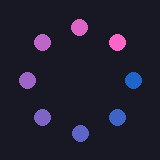




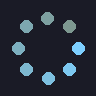

In [1]:
import io
import math
import base64
from PIL import Image, ImageDraw

W, H, N = 96, 96, 24
frames = []
for i in range(N):
    im = Image.new("RGB", (W, H), "#1a1b26")
    d = ImageDraw.Draw(im)
    cx, cy, r = W // 2, H // 2, 30
    for k in range(8):
        ang = math.radians((i * 15) + k * 45)
        x = cx + r * math.cos(ang)
        y = cy + r * math.sin(ang)
        # fade trailing dots
        c = int(255 * (k / 8))
        col = (125, 207 - c // 4, 255 - c // 2)
        d.ellipse([x - 6, y - 6, x + 6, y + 6], fill=col)
    frames.append(im.quantize(colors=64))

buf = io.BytesIO()
frames[0].save(
    buf, format="GIF", save_all=True, append_images=frames[1:],
    loop=0, duration=70, optimize=True, disposal=2,
)
b64 = base64.b64encode(buf.getvalue()).decode("ascii")
print(f"![spinner](data:image/gif;base64,{b64})")

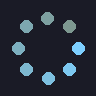


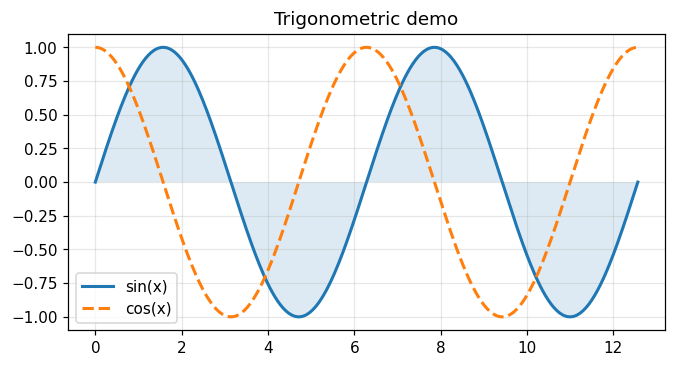

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4 * np.pi, 400)
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=110)
ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', linewidth=2, linestyle='--')
ax.fill_between(x, np.sin(x), 0, alpha=0.15)
ax.set_title('Trigonometric demo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


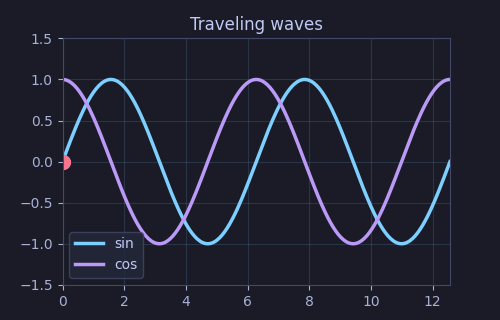

In [3]:
import io
import tempfile
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

fig, ax = plt.subplots(figsize=(5, 3.2), dpi=100, facecolor='#1a1b26')
ax.set_facecolor('#1a1b26')

t = np.linspace(0, 4 * np.pi, 300)
line1, = ax.plot([], [], lw=2.5, color='#7dcfff', label='sin')
line2, = ax.plot([], [], lw=2.5, color='#bb9af7', label='cos')
dot,   = ax.plot([], [], 'o', ms=10, color='#f7768e')

ax.set_xlim(0, 4 * np.pi)
ax.set_ylim(-1.5, 1.5)
ax.tick_params(colors='#a9b1d6')
for s in ax.spines.values(): s.set_color('#414868')
ax.legend(facecolor='#24283b', edgecolor='#414868', labelcolor='#c0caf5')
ax.grid(alpha=0.15, color='#7dcfff')
ax.set_title('Traveling waves', color='#c0caf5')

def update(frame):
    phase = frame * 0.15
    line1.set_data(t, np.sin(t + phase))
    line2.set_data(t, np.cos(t - phase * 0.7))
    x = (frame * 0.2) % (4 * np.pi)
    dot.set_data([x], [np.sin(x + phase)])
    return line1, line2, dot

anim = FuncAnimation(fig, update, frames=60, interval=50, blit=True)

with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as f:
    path = f.name
anim.save(path, writer=PillowWriter(fps=20))
plt.close(fig)
with open(path, 'rb') as f:
    data = f.read()
os.unlink(path)
Image(data=data, format='gif')

## Plain-text output

Stream output renders directly inside the cell box. Long lines
wrap with both side bars intact.


In [4]:
for i in range(5):
    print(f'iteration {i}: {2 ** i}')


iteration 0: 1
iteration 1: 2
iteration 2: 4
iteration 3: 8
iteration 4: 16


In [5]:
# np.einsum
einsum1 = np.arange(1, 5).reshape(2, 2)  # subscripts i, j
einsum2 = np.arange(5, 9).reshape(2, 2)  # subscripts j, k
einsum3 = np.arange(9, 15).reshape(2, 3)  # subscripts k, l
einsum4 = np.arange(15, 27).reshape(2, 3, 2)  # subscripts l, m, n
print(f"einsum1:\n {einsum1}\n")
print(f"einsum2:\n {einsum2}\n")

# transpose
print("# transpose")
transpose1 = np.einsum("ij -> ji", einsum1)
print(np.array_equal(transpose1, einsum1.T)
      and np.array_equal(transpose1, np.transpose(einsum1)))

# sum
print("\n# sum")
# 'ij' means: A[i,j] for all combinations of i,j
sum1 = np.einsum("ij ->", einsum1)
print(np.sum(einsum1) == sum1)
print(np.einsum("ij ->", einsum1))  # sum of all
# keep row, meaning sume across columns - sum of each row
print(np.einsum("ij -> i", einsum1))
# keep column, meaning sum across rows - sum of each column
print(np.einsum("ij -> j", einsum1))

# dot product
print("\n# dot product")
# same as np.einsum("ij, jk", einsum1, einsum2)
np.einsum("ij, jk -> ik", einsum1, einsum2)
np.einsum("ij, jk, kl -> il", einsum1, einsum2, einsum3)

# general rule: any index that is in the input but not in the output should be summed up
print("\n general rule and prac")
lnExample = np.einsum("lmn -> lm", einsum4)
# sum across columns
print(f"lnExample shape: {lnExample.shape}\n einsum4 shape: {einsum4.shape}")
print(f"lnExample\n {lnExample}\n einsum4\n {einsum4}\n")

einsum1:
 [[1 2]
 [3 4]]

einsum2:
 [[5 6]
 [7 8]]

# transpose
True

# sum
True
10
[3 7]
[4 6]

# dot product

 general rule and prac
lnExample shape: (2, 3)
 einsum4 shape: (2, 3, 2)
lnExample
 [[31 35 39]
 [43 47 51]]
 einsum4
 [[[15 16]
  [17 18]
  [19 20]]

 [[21 22]
  [23 24]
  [25 26]]]

